In [ ]:
!pip install -q transformers==4.46.3 datasets accelerate peft bitsandbytes trl==0.12.2
!pip install -q gradio sqlparse rouge-score nltk
!pip install -q huggingface_hub

import nltk
nltk.download('punkt_tab')

print("✅ Dependencies installed. Please restart runtime now.")
print("   Go to: Runtime → Restart runtime")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 127.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 365.7/365.7 kB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 102.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
✅ Dependencies installed. Please restart runtime now.
   Go to: Runtime → Restart runtime


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
import torch
import json
import re
import sqlparse
import numpy as np
import pandas as pd
from datetime import datetime
from collections import Counter

from datasets import load_dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    TrainingArguments,
)
from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training,
    PeftModel,
)
from trl import SFTTrainer
from rouge_score import rouge_scorer

# --- Configuration (Optimized for A100) ---
MODEL_ID = "mistralai/Mistral-7B-Instruct-v0.3"
DATASET_ID = "gretelai/synthetic_text_to_sql"
OUTPUT_DIR = "./mistral-text-to-sql"
MAX_SEQ_LENGTH = 768         # Increased from 512 — captures longer schemas
NUM_TRAIN_SAMPLES = 5000     # Increased from 1000 — better learning with more data
NUM_EVAL_SAMPLES = 100       # Increased from 50 — more robust evaluation
SEED = 42

# Check GPU
print(f"GPU Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    gpu = torch.cuda.get_device_name(0)
    mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU: {gpu} | Memory: {mem:.1f} GB")

    USE_BF16 = torch.cuda.is_bf16_supported()
    print(f"BF16 Support: {USE_BF16}")
else:
    raise RuntimeError("No GPU detected. Please enable GPU: Runtime → Change runtime type → A100 GPU")

print("\n✅ Imports and configuration ready.")


GPU Available: True
GPU: NVIDIA A100-SXM4-40GB | Memory: 42.4 GB
BF16 Support: True

✅ Imports and configuration ready.


In [ ]:
import os
import torch
from google.colab import drive
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel

drive.mount('/content/drive')

# Find model in Drive
model_path = None
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for f in files:
        if f == 'adapter_config.json':
            model_path = root
            print(f"Found model at: {root}")
            break
    if model_path:
        break

if not model_path:
    print("❌ Model not found in Drive!")
else:
    # Copy to local
    !cp -r "{model_path}" ./mistral-text-to-sql

    MODEL_ID = "mistralai/Mistral-7B-Instruct-v0.3"

    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "right"

    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
    )

    print("Loading model...")
    ft_base = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        quantization_config=bnb_config,
        device_map="auto",
        trust_remote_code=True,
        attn_implementation="eager",
    )
    ft_model = PeftModel.from_pretrained(ft_base, "./mistral-text-to-sql")
    ft_model.eval()
    print("✅ Model loaded! Now run Cell 7 (Gradio).")

Mounted at /content/drive
Found model at: /content/drive/MyDrive/mistral-text-to-sql


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/587k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model-00002-of-00003.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

model-00003-of-00003.safetensors:   0%|          | 0.00/4.55G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

✅ Model loaded! Now run Cell 7 (Gradio).


In [ ]:
# --- 3a: Load raw dataset ---
print("Loading Gretel Synthetic Text-to-SQL dataset...")
raw_dataset = load_dataset(DATASET_ID)
print(f"Total training samples available: {len(raw_dataset['train']):,}")

# Inspect a sample
sample = raw_dataset["train"][0]
print(f"\nDataset columns: {list(sample.keys())}")
print(f"\n--- Sample ---")
print(f"SQL Context:\n{sample['sql_context'][:200]}...")
print(f"\nQuestion: {sample['sql_prompt']}")
print(f"\nSQL: {sample['sql']}")
print(f"\nExplanation: {sample['sql_explanation']}")

# --- 3b: Subset if configured ---
if NUM_TRAIN_SAMPLES:
    train_raw = raw_dataset["train"].shuffle(seed=SEED).select(range(NUM_TRAIN_SAMPLES))
    print(f"\nUsing subset: {NUM_TRAIN_SAMPLES:,} training samples")
else:
    train_raw = raw_dataset["train"].shuffle(seed=SEED)
    print(f"\nUsing full dataset: {len(train_raw):,} training samples")

# --- 3c: Format into instruction-tuning prompts ---
SYSTEM_PROMPT = (
    "You are a SQL expert. Given a database schema and a natural language question, "
    "generate the correct SQL query and provide a brief explanation of your reasoning."
)

def format_instruction(sample):
    """Format each sample into Mistral instruct chat template."""
    user_msg = (
        f"### Database Schema:\n{sample['sql_context']}\n\n"
        f"### Question:\n{sample['sql_prompt']}\n\n"
        f"Generate the SQL query and explain your reasoning."
    )

    assistant_msg = (
        f"### SQL Query:\n```sql\n{sample['sql']}\n```\n\n"
        f"### Explanation:\n{sample['sql_explanation']}"
    )

    text = f"<s>[INST] {SYSTEM_PROMPT}\n\n{user_msg} [/INST] {assistant_msg}</s>"
    return {"text": text}

print("\nFormatting dataset...")
formatted_dataset = train_raw.map(format_instruction, remove_columns=train_raw.column_names)

# Train/validation split
split = formatted_dataset.train_test_split(test_size=0.05, seed=SEED)
train_data = split["train"]
val_data = split["test"]

print(f"Train samples: {len(train_data):,}")
print(f"Validation samples: {len(val_data):,}")

# Preview
print(f"\n--- Formatted Sample Preview ---")
print(train_data[0]["text"][:600])
print("...")

# --- 3d: Prepare evaluation set (from unseen data) ---
eval_indices = range(NUM_TRAIN_SAMPLES if NUM_TRAIN_SAMPLES else len(raw_dataset["train"]),
                     (NUM_TRAIN_SAMPLES if NUM_TRAIN_SAMPLES else len(raw_dataset["train"])) + NUM_EVAL_SAMPLES)
eval_raw = raw_dataset["train"].select(eval_indices)
print(f"\nEvaluation samples (unseen): {len(eval_raw):,}")

print("\n✅ Dataset ready.")


Loading Gretel Synthetic Text-to-SQL dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

synthetic_text_to_sql_train.snappy.parqu(…):   0%|          | 0.00/32.4M [00:00<?, ?B/s]

synthetic_text_to_sql_test.snappy.parque(…):   0%|          | 0.00/1.90M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/100000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5851 [00:00<?, ? examples/s]

Total training samples available: 100,000

Dataset columns: ['id', 'domain', 'domain_description', 'sql_complexity', 'sql_complexity_description', 'sql_task_type', 'sql_task_type_description', 'sql_prompt', 'sql_context', 'sql', 'sql_explanation']

--- Sample ---
SQL Context:
CREATE TABLE salesperson (salesperson_id INT, name TEXT, region TEXT); INSERT INTO salesperson (salesperson_id, name, region) VALUES (1, 'John Doe', 'North'), (2, 'Jane Smith', 'South'); CREATE TABLE ...

Question: What is the total volume of timber sold by each salesperson, sorted by salesperson?

SQL: SELECT salesperson_id, name, SUM(volume) as total_volume FROM timber_sales JOIN salesperson ON timber_sales.salesperson_id = salesperson.salesperson_id GROUP BY salesperson_id, name ORDER BY total_volume DESC;

Explanation: Joins timber_sales and salesperson tables, groups sales by salesperson, calculates total volume sold by each salesperson, and orders the results by total volume in descending order.

Using subse

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Train samples: 4,750
Validation samples: 250

--- Formatted Sample Preview ---
<s>[INST] You are a SQL expert. Given a database schema and a natural language question, generate the correct SQL query and provide a brief explanation of your reasoning.

### Database Schema:
CREATE TABLE employees (id INT, name VARCHAR(50), department VARCHAR(20)); INSERT INTO employees (id, name, department) VALUES (1, 'John Doe', 'manufacturing'), (2, 'Jane Smith', 'engineering'), (3, 'Alice Johnson', 'HR'), (4, 'Bob Brown', 'production'), (5, 'Charlie Davis', 'sales'), (6, 'Danielle Green', 'marketing'), (7, 'Eddie Lee', 'marketing');

### Question:
What is the total number of employees i
...

Evaluation samples (unseen): 100

✅ Dataset ready.


In [ ]:
print("Loading Mistral 7B with 4-bit quantization (QLoRA)...\n")

# --- 4a: Quantization config ---
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16 if USE_BF16 else torch.float16,
    bnb_4bit_use_double_quant=True,
)

# --- 4b: Load model ---
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
    attn_implementation="eager",
)

# --- 4c: Load tokenizer ---
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

# --- 4d: Prepare for QLoRA ---
model = prepare_model_for_kbit_training(model)
model.config.use_cache = False

# --- 4e: LoRA adapter config (improved for better results) ---
lora_config = LoraConfig(
    r=16,                          # Increased rank for better capacity
    lora_alpha=32,                 # Scaling factor (alpha/r = 2)
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
)

model = get_peft_model(model, lora_config)

# --- 4f: Print parameter summary ---
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
pct = 100 * trainable_params / total_params

print(f"Total parameters:     {total_params:>14,}")
print(f"Trainable parameters: {trainable_params:>14,}")
print(f"Trainable %:          {pct:>13.2f}%")
print(f"\nGPU Memory Used: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
print(f"GPU Memory Cached: {torch.cuda.memory_reserved() / 1e9:.2f} GB")

print("\n✅ Model loaded and LoRA adapters attached.")


Loading Mistral 7B with 4-bit quantization (QLoRA)...



config.json:   0%|          | 0.00/601 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

model-00001-of-00003.safetensors:   0%|          | 0.00/4.95G [00:00<?, ?B/s]

model-00002-of-00003.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/587k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

Total parameters:      3,800,305,664
Trainable parameters:     41,943,040
Trainable %:                   1.10%

GPU Memory Used: 4.84 GB
GPU Memory Cached: 5.39 GB

✅ Model loaded and LoRA adapters attached.


Configuring training...



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_deprecation.py:100: FutureWarning: Deprecated argument(s) used in '__init__': max_seq_length. Will not be supported from version '0.13.0'.

Deprecated positional argument(s) used in SFTTrainer, please use the SFTConfig to set these arguments instead.
  warnings.warn(message, FutureWarning)
/usr/local/lib/python3.12/dist-packages/trl/trainer/sft_trainer.py:300: UserWarning: You passed a `max_seq_length` argument to the SFTTrainer, the value you passed will override the one in the `SFTConfig`.
  warnings.warn(


Map:   0%|          | 0/4750 [00:00<?, ? examples/s]

Map:   0%|          | 0/250 [00:00<?, ? examples/s]

🚀 Starting fine-tuning...
   Epochs: 3
   Effective batch size: 16
   Learning rate: 0.0002
   Total optimization steps: 0


Step,Training Loss,Validation Loss
50,0.415400,0.414768
100,0.410500,0.406285
150,0.391900,0.396752
200,0.376200,0.392158
250,0.382000,0.387889
300,0.362000,0.383395
350,0.305500,0.392670
400,0.318200,0.385195
450,0.308300,0.385205
500,0.312300,0.377936



📊 Training Complete!
   Final training loss:  0.3205
   Runtime:              3644s (60.7 min)
   Samples/second:       3.91

✅ Model saved to ./mistral-text-to-sql


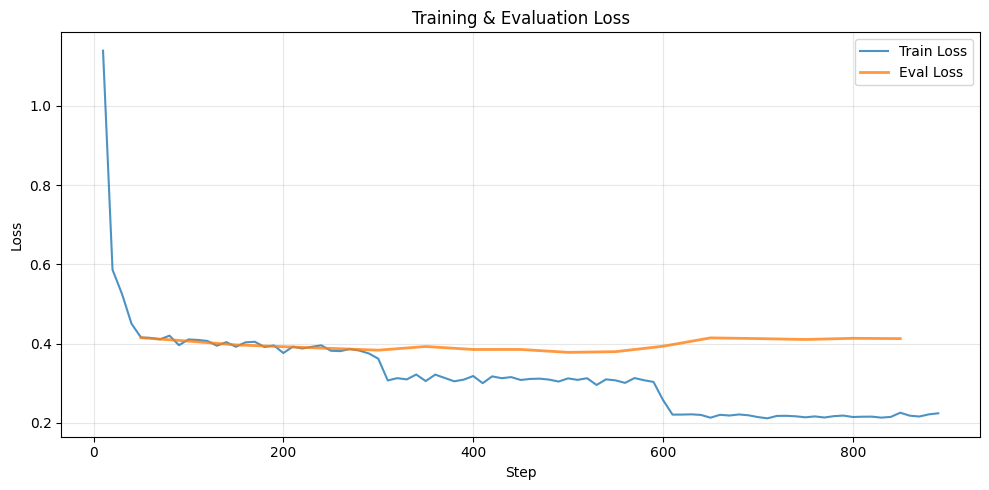

In [ ]:
print("Configuring training...\n")

# --- 5a: Training arguments (optimized for A100) ---
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=8,          # A100 can handle larger batches
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,          # Effective batch = 8 * 2 = 16
    gradient_checkpointing=True,
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_ratio=0.05,
    weight_decay=0.01,
    optim="paged_adamw_8bit",
    fp16=not USE_BF16,                      # A100 supports bf16 natively
    bf16=USE_BF16,
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=50,
    save_strategy="steps",
    save_steps=100,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    report_to="none",
    max_grad_norm=0.3,
    seed=SEED,
)

# --- 5b: Initialize SFTTrainer ---
trainer = SFTTrainer(
    model=model,
    train_dataset=train_data,
    eval_dataset=val_data,
    processing_class=tokenizer,
    args=training_args,
    max_seq_length=MAX_SEQ_LENGTH,
)

# --- 5c: Train ---
print("🚀 Starting fine-tuning...")
print(f"   Epochs: {training_args.num_train_epochs}")
print(f"   Effective batch size: {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"   Learning rate: {training_args.learning_rate}")
print(f"   Total optimization steps: {trainer.state.max_steps if hasattr(trainer.state, 'max_steps') else 'calculating...'}")
print("=" * 60)

train_result = trainer.train()

# --- 5d: Training summary ---
print("\n" + "=" * 60)
print("📊 Training Complete!")
print(f"   Final training loss:  {train_result.training_loss:.4f}")
print(f"   Runtime:              {train_result.metrics['train_runtime']:.0f}s ({train_result.metrics['train_runtime']/60:.1f} min)")
print(f"   Samples/second:       {train_result.metrics['train_samples_per_second']:.2f}")

# --- 5e: Save model ---
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(f"\n✅ Model saved to {OUTPUT_DIR}")

# --- 5f: Plot training loss ---
import matplotlib.pyplot as plt

log_history = trainer.state.log_history
train_losses = [(x["step"], x["loss"]) for x in log_history if "loss" in x]
eval_losses = [(x["step"], x["eval_loss"]) for x in log_history if "eval_loss" in x]

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
if train_losses:
    steps, losses = zip(*train_losses)
    ax.plot(steps, losses, label="Train Loss", alpha=0.8)
if eval_losses:
    steps, losses = zip(*eval_losses)
    ax.plot(steps, losses, label="Eval Loss", alpha=0.8, linewidth=2)
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title("Training & Evaluation Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive')

if os.path.exists("./mistral-text-to-sql"):
    !cp -r ./mistral-text-to-sql /content/drive/MyDrive/mistral-text-to-sql
    if os.path.exists("/content/drive/MyDrive/mistral-text-to-sql"):
        saved_files = os.listdir("/content/drive/MyDrive/mistral-text-to-sql")
        print(f"✅ Model saved to Google Drive!")
        print(f"   Files: {saved_files}")
    else:
        print("❌ Save verification failed!")
else:
    print("❌ Local model not found. Make sure Cell 5 completed successfully.")

Mounted at /content/drive
✅ Model saved to Google Drive!
   Files: ['checkpoint-891', 'checkpoint-500', 'README.md', 'adapter_model.safetensors', 'adapter_config.json', 'tokenizer_config.json', 'special_tokens_map.json', 'tokenizer.model', 'tokenizer.json', 'training_args.bin']


📊 EVALUATION: BASE MODEL (Before Fine-Tuning)
Loading base model for evaluation...


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Running evaluation on 100 samples...

  Processed 25/100...
  Processed 50/100...
  Processed 75/100...
  Processed 100/100...

📊 EVALUATION: FINE-TUNED MODEL (After Fine-Tuning)
Loading fine-tuned model...


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Running evaluation on 100 samples...

  Processed 25/100...
  Processed 50/100...
  Processed 75/100...
  Processed 100/100...

📊 COMPARISON REPORT: BASE vs FINE-TUNED
               Metric Base Model Fine-Tuned Improvement % Change
    Exact Match (SQL)     0.1100     0.3300     +0.2200  +200.0%
     Keyword F1 (SQL)     0.7294     0.8029     +0.0735   +10.1%
Structural Similarity     0.9456     0.9522     +0.0067    +0.7%
ROUGE-1 (Explanation)     0.0000     0.3557     +0.3557    +inf%
ROUGE-2 (Explanation)     0.0000     0.2267     +0.2267    +inf%
ROUGE-L (Explanation)     0.0000     0.2775     +0.2775    +inf%


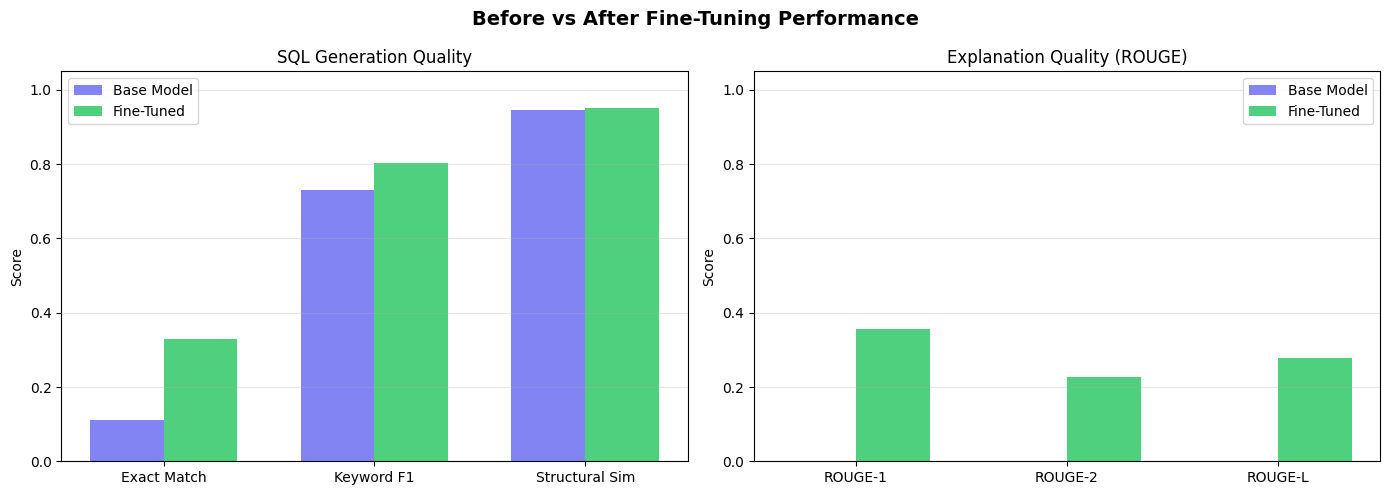


📝 EXAMPLE COMPARISONS (5 samples)

──────────────────────────────────────────────────
Example 1
──────────────────────────────────────────────────
Question: What is the minimum age of artists who have exhibited in galleries located in the Warehouse District?

🎯 Gold SQL:
   SELECT MIN(age) FROM artists JOIN galleries ON artists.gallery_id = galleries.id WHERE galleries.location = 'Warehouse District';

❌ Base Model SQL:
   SELECT MIN(age) AS min_age
FROM artists
JOIN galleries ON artists.gallery_id = galleries.id
WHERE galleries.location = 'Warehouse District';

✅ Fine-Tuned SQL:
   SELECT MIN(age) FROM artists WHERE gallery_id IN (SELECT id FROM galleries WHERE location = 'Warehouse District');

   Exact Match — Base: 0.0 | Fine-Tuned: 0.0
   Keyword F1  — Base: 0.938 | Fine-Tuned: 0.516

──────────────────────────────────────────────────
Example 2
──────────────────────────────────────────────────
Question: Get the average age of fans in each country and display the result in ascend

In [ ]:
import gc

# --- 6a: Helper functions ---
def build_eval_prompt(sample):
    """Build evaluation prompt from raw sample."""
    user_msg = (
        f"### Database Schema:\n{sample['sql_context']}\n\n"
        f"### Question:\n{sample['sql_prompt']}\n\n"
        f"Generate the SQL query and explain your reasoning."
    )
    return f"<s>[INST] {SYSTEM_PROMPT}\n\n{user_msg} [/INST]"

def extract_sql(text):
    """Extract SQL query from model output."""
    match = re.search(r"```sql\s*(.*?)\s*```", text, re.DOTALL | re.IGNORECASE)
    if match:
        return match.group(1).strip()
    match = re.search(r"###?\s*SQL\s*Query:?\s*(.*?)(?:###|Explanation|$)", text, re.DOTALL | re.IGNORECASE)
    if match:
        sql = match.group(1).strip().strip("`").strip()
        if sql:
            return sql
    match = re.search(r"(SELECT\s+.*?;)", text, re.DOTALL | re.IGNORECASE)
    if match:
        return match.group(1).strip()
    return text.strip()

def extract_explanation(text):
    """Extract explanation from model output."""
    match = re.search(r"###?\s*Explanation:?\s*(.*?)$", text, re.DOTALL | re.IGNORECASE)
    if match:
        return match.group(1).strip()
    return ""

def normalize_sql(sql):
    """Normalize SQL for comparison."""
    try:
        formatted = sqlparse.format(
            sql, reindent=False, keyword_case="upper",
            strip_comments=True, strip_whitespace=True
        )
        return " ".join(formatted.split()).strip().rstrip(";")
    except:
        return " ".join(sql.split()).upper().strip().rstrip(";")

def compute_exact_match(pred_sql, gold_sql):
    """Check if normalized SQL matches exactly."""
    return 1.0 if normalize_sql(pred_sql) == normalize_sql(gold_sql) else 0.0

def compute_keyword_overlap(pred_sql, gold_sql):
    """Compute keyword-level F1 between predicted and gold SQL."""
    pred_tokens = normalize_sql(pred_sql).split()
    gold_tokens = normalize_sql(gold_sql).split()

    if not gold_tokens:
        return 0.0

    pred_counter = Counter(pred_tokens)
    gold_counter = Counter(gold_tokens)

    common = sum((pred_counter & gold_counter).values())
    if common == 0:
        return 0.0

    precision = common / len(pred_tokens) if pred_tokens else 0
    recall = common / len(gold_tokens)
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    return f1

def compute_structural_similarity(pred_sql, gold_sql):
    """Check if SQL uses the same clauses (SELECT, WHERE, JOIN, etc.)."""
    clauses = ["SELECT", "FROM", "WHERE", "JOIN", "GROUP BY", "ORDER BY", "HAVING", "LIMIT", "UNION"]
    pred_upper = pred_sql.upper()
    gold_upper = gold_sql.upper()

    matches = sum(1 for c in clauses if (c in pred_upper) == (c in gold_upper))
    return matches / len(clauses)

def generate_response(model, tokenizer, prompt, max_new_tokens=300):
    """Generate response from model."""
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=MAX_SEQ_LENGTH).to(model.device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.1,
            do_sample=True,
            top_p=0.95,
            repetition_penalty=1.15,
            pad_token_id=tokenizer.eos_token_id,
        )
    response = tokenizer.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    return response

# --- 6b: Evaluate BASE model (before fine-tuning) ---
print("=" * 60)
print("📊 EVALUATION: BASE MODEL (Before Fine-Tuning)")
print("=" * 60)

# Free memory and reload base model
del model
del trainer
gc.collect()
torch.cuda.empty_cache()

print("Loading base model for evaluation...")
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
    attn_implementation="eager",
)
base_model.eval()

print(f"Running evaluation on {NUM_EVAL_SAMPLES} samples...\n")

base_results = []
for i, sample in enumerate(eval_raw):
    prompt = build_eval_prompt(sample)
    response = generate_response(base_model, tokenizer, prompt)

    pred_sql = extract_sql(response)
    gold_sql = sample["sql"]
    pred_explanation = extract_explanation(response)
    gold_explanation = sample["sql_explanation"]

    exact_match = compute_exact_match(pred_sql, gold_sql)
    keyword_f1 = compute_keyword_overlap(pred_sql, gold_sql)
    structural = compute_structural_similarity(pred_sql, gold_sql)

    scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)
    rouge_scores = scorer.score(gold_explanation, pred_explanation) if pred_explanation else {
        "rouge1": type("", (), {"fmeasure": 0.0})(),
        "rouge2": type("", (), {"fmeasure": 0.0})(),
        "rougeL": type("", (), {"fmeasure": 0.0})(),
    }

    base_results.append({
        "exact_match": exact_match,
        "keyword_f1": keyword_f1,
        "structural_sim": structural,
        "rouge1": rouge_scores["rouge1"].fmeasure,
        "rouge2": rouge_scores["rouge2"].fmeasure,
        "rougeL": rouge_scores["rougeL"].fmeasure,
        "pred_sql": pred_sql,
        "gold_sql": gold_sql,
        "pred_explanation": pred_explanation,
    })

    if (i + 1) % 25 == 0:
        print(f"  Processed {i+1}/{NUM_EVAL_SAMPLES}...")

# --- 6c: Evaluate FINE-TUNED model ---
print("\n" + "=" * 60)
print("📊 EVALUATION: FINE-TUNED MODEL (After Fine-Tuning)")
print("=" * 60)

del base_model
gc.collect()
torch.cuda.empty_cache()

print("Loading fine-tuned model...")
ft_base = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
    attn_implementation="eager",
)
ft_model = PeftModel.from_pretrained(ft_base, OUTPUT_DIR)
ft_model.eval()

print(f"Running evaluation on {NUM_EVAL_SAMPLES} samples...\n")

ft_results = []
for i, sample in enumerate(eval_raw):
    prompt = build_eval_prompt(sample)
    response = generate_response(ft_model, tokenizer, prompt)

    pred_sql = extract_sql(response)
    gold_sql = sample["sql"]
    pred_explanation = extract_explanation(response)
    gold_explanation = sample["sql_explanation"]

    exact_match = compute_exact_match(pred_sql, gold_sql)
    keyword_f1 = compute_keyword_overlap(pred_sql, gold_sql)
    structural = compute_structural_similarity(pred_sql, gold_sql)

    scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)
    rouge_scores = scorer.score(gold_explanation, pred_explanation) if pred_explanation else {
        "rouge1": type("", (), {"fmeasure": 0.0})(),
        "rouge2": type("", (), {"fmeasure": 0.0})(),
        "rougeL": type("", (), {"fmeasure": 0.0})(),
    }

    ft_results.append({
        "exact_match": exact_match,
        "keyword_f1": keyword_f1,
        "structural_sim": structural,
        "rouge1": rouge_scores["rouge1"].fmeasure,
        "rouge2": rouge_scores["rouge2"].fmeasure,
        "rougeL": rouge_scores["rougeL"].fmeasure,
        "pred_sql": pred_sql,
        "gold_sql": gold_sql,
        "pred_explanation": pred_explanation,
    })

    if (i + 1) % 25 == 0:
        print(f"  Processed {i+1}/{NUM_EVAL_SAMPLES}...")

# --- 6d: Comparison Report ---
print("\n" + "=" * 60)
print("📊 COMPARISON REPORT: BASE vs FINE-TUNED")
print("=" * 60)

metrics = ["exact_match", "keyword_f1", "structural_sim", "rouge1", "rouge2", "rougeL"]
metric_labels = {
    "exact_match": "Exact Match (SQL)",
    "keyword_f1": "Keyword F1 (SQL)",
    "structural_sim": "Structural Similarity",
    "rouge1": "ROUGE-1 (Explanation)",
    "rouge2": "ROUGE-2 (Explanation)",
    "rougeL": "ROUGE-L (Explanation)",
}

comparison_data = []
for m in metrics:
    base_avg = np.mean([r[m] for r in base_results])
    ft_avg = np.mean([r[m] for r in ft_results])
    improvement = ft_avg - base_avg
    pct_change = (improvement / base_avg * 100) if base_avg > 0 else float('inf')

    comparison_data.append({
        "Metric": metric_labels[m],
        "Base Model": f"{base_avg:.4f}",
        "Fine-Tuned": f"{ft_avg:.4f}",
        "Improvement": f"{improvement:+.4f}",
        "% Change": f"{pct_change:+.1f}%",
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# --- 6e: Visualization ---
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sql_metrics = ["exact_match", "keyword_f1", "structural_sim"]
sql_labels = ["Exact Match", "Keyword F1", "Structural Sim"]
base_vals = [np.mean([r[m] for r in base_results]) for m in sql_metrics]
ft_vals = [np.mean([r[m] for r in ft_results]) for m in sql_metrics]

x = np.arange(len(sql_labels))
w = 0.35
axes[0].bar(x - w/2, base_vals, w, label="Base Model", color="#6366f1", alpha=0.8)
axes[0].bar(x + w/2, ft_vals, w, label="Fine-Tuned", color="#22c55e", alpha=0.8)
axes[0].set_ylabel("Score")
axes[0].set_title("SQL Generation Quality")
axes[0].set_xticks(x)
axes[0].set_xticklabels(sql_labels)
axes[0].legend()
axes[0].set_ylim(0, 1.05)
axes[0].grid(axis="y", alpha=0.3)

rouge_metrics = ["rouge1", "rouge2", "rougeL"]
rouge_labels = ["ROUGE-1", "ROUGE-2", "ROUGE-L"]
base_vals = [np.mean([r[m] for r in base_results]) for m in rouge_metrics]
ft_vals = [np.mean([r[m] for r in ft_results]) for m in rouge_metrics]

x = np.arange(len(rouge_labels))
axes[1].bar(x - w/2, base_vals, w, label="Base Model", color="#6366f1", alpha=0.8)
axes[1].bar(x + w/2, ft_vals, w, label="Fine-Tuned", color="#22c55e", alpha=0.8)
axes[1].set_ylabel("Score")
axes[1].set_title("Explanation Quality (ROUGE)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(rouge_labels)
axes[1].legend()
axes[1].set_ylim(0, 1.05)
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("Before vs After Fine-Tuning Performance", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# --- 6f: Show example comparisons ---
print("\n" + "=" * 60)
print("📝 EXAMPLE COMPARISONS (5 samples)")
print("=" * 60)

for i in range(min(5, NUM_EVAL_SAMPLES)):
    sample = eval_raw[i]
    print(f"\n{'─' * 50}")
    print(f"Example {i+1}")
    print(f"{'─' * 50}")
    print(f"Question: {sample['sql_prompt']}")
    print(f"\n🎯 Gold SQL:\n   {sample['sql']}")
    print(f"\n❌ Base Model SQL:\n   {base_results[i]['pred_sql'][:200]}")
    print(f"\n✅ Fine-Tuned SQL:\n   {ft_results[i]['pred_sql'][:200]}")
    print(f"\n   Exact Match — Base: {base_results[i]['exact_match']} | Fine-Tuned: {ft_results[i]['exact_match']}")
    print(f"   Keyword F1  — Base: {base_results[i]['keyword_f1']:.3f} | Fine-Tuned: {ft_results[i]['keyword_f1']:.3f}")


In [ ]:
import gradio as gr
import sqlparse
import re
import torch

# Re-define constants needed for this cell
MAX_SEQ_LENGTH = 512

SYSTEM_PROMPT = (
    "You are a SQL expert. Given a database schema and a natural language question, "
    "generate the correct SQL query and provide a brief explanation of your reasoning."
)

def extract_sql(text):
    """Extract SQL query from model output."""
    match = re.search(r"```sql\s*(.*?)\s*```", text, re.DOTALL | re.IGNORECASE)
    if match:
        return match.group(1).strip()
    match = re.search(r"###?\s*SQL\s*Query:?\s*(.*?)(?:###|Explanation|$)", text, re.DOTALL | re.IGNORECASE)
    if match:
        sql = match.group(1).strip().strip("`").strip()
        if sql:
            return sql
    match = re.search(r"(SELECT\s+.*?;)", text, re.DOTALL | re.IGNORECASE)
    if match:
        return match.group(1).strip()
    return text.strip()

def extract_explanation(text):
    """Extract explanation from model output."""
    match = re.search(r"###?\s*Explanation:?\s*(.*?)$", text, re.DOTALL | re.IGNORECASE)
    if match:
        return match.group(1).strip()
    return ""

def query_model(schema, question, temperature, max_tokens):
    """Generate SQL from schema and question using fine-tuned model."""
    if not schema.strip() or not question.strip():
        return "⚠️ Please provide both a database schema and a question.", ""

    user_msg = (
        f"### Database Schema:\n{schema}\n\n"
        f"### Question:\n{question}\n\n"
        f"Generate the SQL query and explain your reasoning."
    )
    prompt = f"<s>[INST] {SYSTEM_PROMPT}\n\n{user_msg} [/INST]"

    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=MAX_SEQ_LENGTH).to(ft_model.device)

    with torch.no_grad():
        outputs = ft_model.generate(
            **inputs,
            max_new_tokens=int(max_tokens),
            temperature=float(temperature),
            do_sample=True if float(temperature) > 0 else False,
            top_p=0.95,
            repetition_penalty=1.15,
            pad_token_id=tokenizer.eos_token_id,
        )

    response = tokenizer.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)

    sql = extract_sql(response)
    explanation = extract_explanation(response)

    try:
        formatted_sql = sqlparse.format(sql, reindent=True, keyword_case="upper")
    except:
        formatted_sql = sql

    return formatted_sql, explanation if explanation else "No explanation generated."

# --- Example schemas for demo ---
EXAMPLE_SCHEMAS = [
    [
        "CREATE TABLE employees (\n  id INT PRIMARY KEY,\n  name VARCHAR(100),\n  department VARCHAR(50),\n  salary DECIMAL(10,2),\n  hire_date DATE\n);",
        "Find the top 3 highest paid employees in each department."
    ],
    [
        "CREATE TABLE orders (\n  order_id INT PRIMARY KEY,\n  customer_id INT,\n  product VARCHAR(100),\n  quantity INT,\n  price DECIMAL(10,2),\n  order_date DATE\n);\n\nCREATE TABLE customers (\n  customer_id INT PRIMARY KEY,\n  name VARCHAR(100),\n  email VARCHAR(100),\n  city VARCHAR(50)\n);",
        "Find the total revenue per city for orders placed in 2024."
    ],
    [
        "CREATE TABLE students (\n  student_id INT PRIMARY KEY,\n  name VARCHAR(100),\n  major VARCHAR(50),\n  gpa DECIMAL(3,2)\n);\n\nCREATE TABLE enrollments (\n  enrollment_id INT PRIMARY KEY,\n  student_id INT,\n  course_name VARCHAR(100),\n  grade CHAR(2)\n);",
        "Find students who have taken more than 5 courses and have a GPA above 3.5."
    ],
]

# --- Build Gradio UI ---
with gr.Blocks(
    title="Text-to-SQL Generator",
    theme=gr.themes.Soft(primary_hue="indigo"),
) as demo:

    gr.Markdown(
        """
        # 🗄️ Text-to-SQL Generator
        ### Fine-tuned Mistral 7B for SQL Query Generation

        Enter your database schema and ask a question in natural language.
        The model will generate the SQL query and explain its reasoning.
        """
    )

    with gr.Row():
        with gr.Column(scale=1):
            schema_input = gr.Textbox(
                label="📋 Database Schema (DDL)",
                placeholder="CREATE TABLE employees (\n  id INT PRIMARY KEY,\n  name VARCHAR(100),\n  ...\n);",
                lines=8,
            )
            question_input = gr.Textbox(
                label="❓ Your Question (Natural Language)",
                placeholder="e.g., Find all employees who earn more than the average salary...",
                lines=2,
            )

            with gr.Row():
                temp_slider = gr.Slider(
                    minimum=0.0, maximum=1.0, value=0.1, step=0.05,
                    label="Temperature",
                )
                max_tokens_slider = gr.Slider(
                    minimum=64, maximum=512, value=300, step=32,
                    label="Max Tokens",
                )

            generate_btn = gr.Button("🚀 Generate SQL", variant="primary", size="lg")

        with gr.Column(scale=1):
            sql_output = gr.Code(
                label="📝 Generated SQL Query",
                language="sql",
                lines=8,
            )
            explanation_output = gr.Textbox(
                label="💡 Explanation",
                lines=5,
            )

    gr.Markdown("### 📚 Example Queries")
    gr.Examples(
        examples=EXAMPLE_SCHEMAS,
        inputs=[schema_input, question_input],
        label="Click an example to try it:",
    )

    generate_btn.click(
        fn=query_model,
        inputs=[schema_input, question_input, temp_slider, max_tokens_slider],
        outputs=[sql_output, explanation_output],
    )

    question_input.submit(
        fn=query_model,
        inputs=[schema_input, question_input, temp_slider, max_tokens_slider],
        outputs=[sql_output, explanation_output],
    )

# Launch
demo.launch(share=True, debug=True)
print("\n✅ Gradio interface launched! Use the public URL to share.")

/tmp/ipykernel_7688/1728240757.py:90: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://6794771eaf55b57291.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
